# Лабораторная работа 3.
# Сетевые алгоритмы. Динамические алгоритмы поиска путей.


## Выполнил студент группы Козырев Матвей БВТ2301
***

### Задание

1.  Реализовать алгоритм поиска кратчайшего расстояния между двумя вершинами ориентированного взвешенного графа в соответствии с вариантом.

2.  Предусмотреть задание графа в виде матрицы смежности/инцидентности, читаемой из файла, либо графически с помощью пользовательского интерфейса.

3.  Разработать графический интерфейс пользователя с визуализацией графа и отображением кратчайшего расстояния между задаваемыми пользователем вершинами.

4. По результатам работы проанализировать временную сложность работы заданного алгоритма в зависимости от числа узлов и ребер графа.
Данные представить в виде таблицы.



### Алгоритмы:

Алгоритм Флойда-Уоршелла| Алгоритм Дейкстры | Алгоритм Беллмана-Форда | Алгоритм Джонсона| Алгоритм Левита | Алгоритм Йена



### Выполнение:

In [35]:
def read_adjacency_matrix(filename):
    with open(filename, 'r') as f:
        lines = [line.strip() for line in f if line.strip() and not line.startswith('#')]

    matrix = [list(map(int, line.split())) for line in lines]
    graph = {}

    for i in range(len(matrix)):
        graph[i] = []
        for j in range(len(matrix[i])):
            if matrix[i][j] != 0:
                graph[i].append((j, matrix[i][j]))

    return graph

def read_incidence_matrix(filename):
    with open(filename, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    weights = list(map(int, lines[-1].split()))
    incidence = [list(map(int, line.split())) for line in lines[:-1]]

    graph = {i: [] for i in range(len(incidence))}

    for j in range(len(weights)):
        start = None
        end = None
        for i in range(len(incidence)):
            if incidence[i][j] == 1:
                start = i
            elif incidence[i][j] == -1:
                end = i

        if start is not None and end is not None:
            graph[start].append((end, weights[j]))

    return graph


Алгоритм Флойда-Уоршелла

In [36]:
def floyd_warshall(graph, start, end):
    start = int(start)
    end = int(end)

    vertices = list(graph.keys())
    n = len(vertices)
    vertex_to_index = {v: i for i, v in enumerate(vertices)}
    index_to_vertex = {i: v for i, v in enumerate(vertices)}

    dist = [[float('inf')] * n for _ in range(n)]
    next_node = [[-1] * n for _ in range(n)]

    for i in range(n):
        dist[i][i] = 0
        next_node[i][i] = i

    for u in graph:
        for v, w in graph[u]:
            i = vertex_to_index[u]
            j = vertex_to_index[v]
            dist[i][j] = w
            next_node[i][j] = j

    for k in range(n):
        for i in range(n):
            for j in range(n):
                if dist[i][j] > dist[i][k] + dist[k][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
                    next_node[i][j] = next_node[i][k]

    start_idx = vertex_to_index[start]
    end_idx = vertex_to_index[end]

    if dist[start_idx][end_idx] == float('inf'):
        return float('inf'), []

    path = []
    current = start_idx
    while current != end_idx:
        if next_node[current][end_idx] == -1:
            return float('inf'), []
        path.append(index_to_vertex[current])
        current = next_node[current][end_idx]
    path.append(index_to_vertex[end_idx])

    return dist[start_idx][end_idx], [str(v) for v in path]

Алгоритм Дейкстры

In [37]:
import heapq

def dijkstra(graph, start, end):
    start = int(start)
    end = int(end)

    distances = {vertex: float('inf') for vertex in graph}
    distances[start] = 0
    previous = {vertex: None for vertex in graph}
    heap = [(0, start)]

    while heap:
        current_dist, current_vertex = heapq.heappop(heap)

        if current_vertex == end:
            break

        if current_dist > distances[current_vertex]:
            continue

        for neighbor, weight in graph[current_vertex]:
            distance = current_dist + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_vertex
                heapq.heappush(heap, (distance, neighbor))

    path = []
    current = end
    while current is not None:
        path.append(str(current))
        current = previous[current]
    path.reverse()

    return distances[end], path

Алгоритм Беллмана-Форда

In [38]:
def bellman_ford(graph, start, end):
    start = int(start)
    end = int(end)

    distances = {vertex: float('inf') for vertex in graph}
    distances[start] = 0
    previous = {vertex: None for vertex in graph}

    for _ in range(len(graph) - 1):
        for u in graph:
            for v, w in graph[u]:
                if distances[u] + w < distances[v]:
                    distances[v] = distances[u] + w
                    previous[v] = u

    for u in graph:
        for v, w in graph[u]:
            if distances[u] + w < distances[v]:
                raise ValueError("Граф содержит отрицательный цикл")

    if distances[end] == float('inf'):
        return float('inf'), []

    path = []
    current = end
    while current is not None:
        path.append(str(current))
        current = previous[current]
    path.reverse()

    return distances[end], path

Алгоритм Джонсона

In [39]:
def johnson(graph, start, end):
    if not graph:
        return float('inf'), []

    try:
        start = int(start) if start is not None else None
        end = int(end) if end is not None else None
    except (TypeError, ValueError):
        return float('inf'), []

    if start is None or end is None or start not in graph or end not in graph:
        return float('inf'), []

    vertices = list(graph.keys())
    s = max(vertices) + 1 if vertices else 0
    modified_graph = {u: edges.copy() for u, edges in graph.items()}
    modified_graph[s] = [(v, 0) for v in vertices]

    try:
        h = bellman_ford_for_johnson(modified_graph, s)
    except ValueError as e:
        if "Negative cycle" in str(e):
            return float('inf'), []
        raise

    reweighted_graph = {u: [] for u in graph}
    for u in graph:
        for v, w in graph[u]:
            new_weight = w + h[u] - h[v]
            reweighted_graph[u].append((v, new_weight))

    distances = {}
    predecessors = {}

    for u in graph:
        dist, pred = dijkstra_for_johnson(reweighted_graph, u)
        distances[u] = {v: d + h[v] - h[u] for v, d in dist.items()}
        predecessors[u] = pred

    if end not in distances[start] or distances[start][end] == float('inf'):
        return float('inf'), []

    path = []
    current = end
    while current != start:
        if current is None or current not in predecessors[start]:
            return float('inf'), []
        path.append(str(current))
        current = predecessors[start][current]
    path.append(str(start))
    path.reverse()

    return distances[start][end], path

def bellman_ford_for_johnson(graph, start):
    distances = {v: float('inf') for v in graph}
    predecessors = {v: None for v in graph}
    distances[start] = 0

    for _ in range(len(graph) - 1):
        for u in graph:
            for v, w in graph[u]:
                if distances[u] + w < distances[v]:
                    distances[v] = distances[u] + w
                    predecessors[v] = u

    for u in graph:
        for v, w in graph[u]:
            if distances[u] + w < distances[v]:
                raise ValueError("Negative cycle detected")

    return distances

def dijkstra_for_johnson(graph, start):
    import heapq
    distances = {v: float('inf') for v in graph}
    predecessors = {v: None for v in graph}
    distances[start] = 0
    heap = [(0, start)]

    while heap:
        current_dist, u = heapq.heappop(heap)
        if current_dist > distances[u]:
            continue

        for v, w in graph.get(u, []):
            if v not in distances:
                continue
            distance = current_dist + w
            if distance < distances[v]:
                distances[v] = distance
                predecessors[v] = u
                heapq.heappush(heap, (distance, v))

    return distances, predecessors

Алгоритм Левита

In [40]:
from collections import deque

def levit(graph, start, end):
    start = int(start)
    end = int(end)

    distances = {vertex: float('inf') for vertex in graph}
    distances[start] = 0
    previous = {vertex: None for vertex in graph}

    queues = [deque(), deque(), deque()]
    queues[0].append(start)
    in_queue = {vertex: 0 for vertex in graph}

    while any(queues):
        current = None
        if queues[1]:
            current = queues[1].popleft()
        elif queues[0]:
            current = queues[0].popleft()
        else:
            current = queues[2].pop()

        if current == end:
            break

        for neighbor, weight in graph[current]:
            new_dist = distances[current] + weight
            if new_dist < distances[neighbor]:
                distances[neighbor] = new_dist
                previous[neighbor] = current

                if in_queue[neighbor] == 0:
                    queues[0].append(neighbor)
                elif in_queue[neighbor] == 1:
                    pass
                else:
                    queues[1].append(neighbor)
                in_queue[neighbor] = 1

    if distances[end] == float('inf'):
        return float('inf'), []

    path = []
    current = end
    while current is not None:
        path.append(str(current))
        current = previous[current]
    path.reverse()

    return distances[end], path

Алгоритм Йена

In [41]:
def yen(graph, start, end, K=3):
    start = int(start)
    end = int(end)

    shortest_distance, shortest_path = dijkstra(graph, start, end)
    if shortest_distance == float('inf'):
        return [(float('inf'), [])] * K

    A = [(shortest_distance, shortest_path)]
    B = []

    for k in range(1, K):
        temp_graph = {u: [(v, w) for v, w in edges] for u, edges in graph.items()}

        for i in range(len(A[k-1][1]) - 1):
            spur_node = int(A[k-1][1][i])
            root_path = A[k-1][1][:i+1]

            edges_removed = []
            for path in A:
                if len(path[1]) > i and path[1][:i+1] == root_path:
                    u = int(path[1][i])
                    v = int(path[1][i+1])
                    for j, (neighbor, w) in enumerate(temp_graph.get(u, [])):
                        if neighbor == v:
                            edges_removed.append((u, v, w))
                            temp_graph[u] = [e for e in temp_graph[u] if e != (v, w)]
                            break

            spur_distance, spur_path = dijkstra(temp_graph, spur_node, end)

            if spur_distance != float('inf'):
                total_path = root_path[:-1] + spur_path
                valid = True
                for m in range(len(total_path) - 1):
                    u = int(total_path[m])
                    v = int(total_path[m+1])
                    if not any(neighbor == v for neighbor, _ in graph.get(u, [])):
                        valid = False
                        break

                if valid:
                    total_distance = sum_weights(graph, total_path)
                    if not any(p[1] == total_path for p in B):
                        B.append((total_distance, total_path))

        if not B:
            break

        B.sort()
        A.append(B[0])
        B.pop(0)

    while len(A) < K:
        A.append((float('inf'), []))

    return A[:K]

def sum_weights(graph, path):
    total = 0
    for i in range(len(path) - 1):
        u = int(path[i])
        v = int(path[i+1])
        found = False
        for neighbor, w in graph.get(u, []):
            if neighbor == v:
                total += w
                found = True
                break
        if not found:
            return float('inf')
    return total

Название файла: graph_inc.txt

Доступные алгоритмы: dijkstra, floyd, bellman, johnson, levit, yen
Тип матрицы (adj/inc): inc
Алгоритм: yen
Начальная вершина: 0
Конечная вершина: 2

Исходный граф:


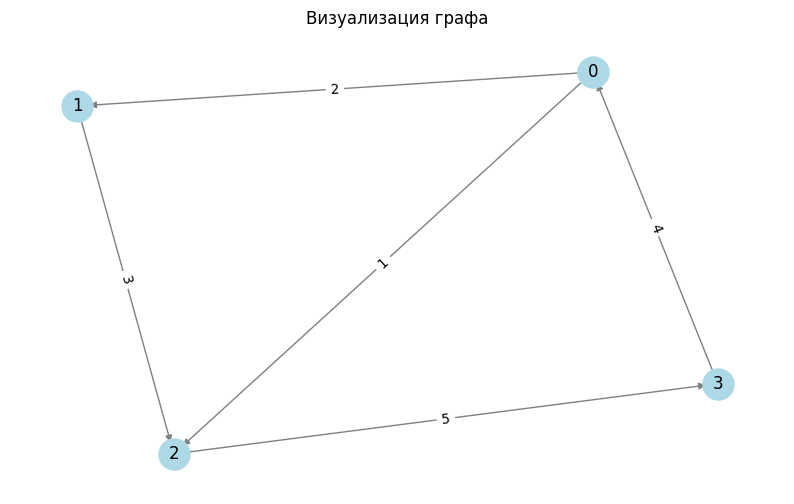


Кратчайшее расстояние: 1
Путь: 0 -> 2

Граф с кратчайшим путем:


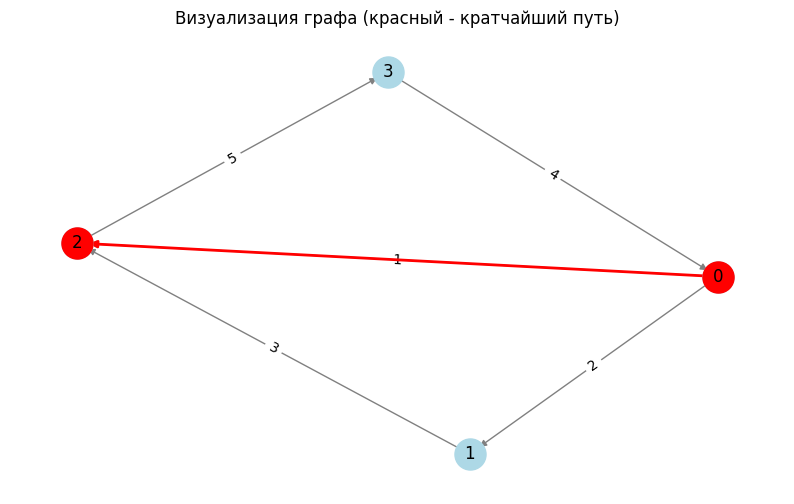

In [48]:
import heapq
from collections import deque
import networkx as nx
import matplotlib.pyplot as plt
from google.colab import files

def draw_graph(graph, path=None):
    G = nx.DiGraph()

    for u in graph:
        for (v, w) in graph[u]:
            G.add_edge(u, v, weight=w)

    pos = nx.spring_layout(G)
    plt.figure(figsize=(10, 6))

    nx.draw_networkx_edges(G, pos, edge_color='gray', width=1)

    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)

    nx.draw_networkx_labels(G, pos)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path:
        path_edges = [(int(path[i]), int(path[i+1])) for i in range(len(path)-1)]
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
        nx.draw_networkx_nodes(G, pos, nodelist=[int(v) for v in path], node_color='red', node_size=500)

    plt.title("Визуализация графа" + (" (красный - кратчайший путь)" if path else ""))
    plt.axis('off')
    plt.show()

def main():
    filename = input('Название файла: ')

    print("\nДоступные алгоритмы: dijkstra, floyd, bellman, johnson, levit, yen")
    matrix_type = input("Тип матрицы (adj/inc): ").strip().lower()
    algo = input("Алгоритм: ").strip().lower()
    start = input("Начальная вершина: ").strip()
    end = input("Конечная вершина: ").strip()

    try:
        if matrix_type == 'adj':
            graph = read_adjacency_matrix(f'/content/{filename}')
        elif matrix_type == 'inc':
            graph = read_incidence_matrix(f'/content/{filename}')
        else:
            print("Ошибка: используйте 'adj' или 'inc'")
            return

        print("\nИсходный граф:")
        draw_graph(graph)

        algorithm_map = {
            'dijkstra': dijkstra,
            'floyd': floyd_warshall,
            'bellman': bellman_ford,
            'johnson': johnson,
            'levit': levit,
            'yen': lambda g, s, e: yen(g, s, e, 3)[0]
        }

        if algo not in algorithm_map:
            print("Ошибка: неизвестный алгоритм")
            return

        distance, path = algorithm_map[algo](graph, start, end)

        if distance == float('inf'):
            print(f"\nПути между {start} и {end} не существует!")
        else:
            print(f"\nКратчайшее расстояние: {distance}")
            print(f"Путь: {' -> '.join(path)}")

            print("\nГраф с кратчайшим путем:")
            draw_graph(graph, path)

    except Exception as e:
        print(f"Ошибка: {e}")

if __name__ == "__main__":
    main()

Алгоритм: Флойда-Уоршелла |  Дейкстры |  Беллмана-Форда | Джонсона | Левита | Йена

Сложность: O(V³) | O(V²) | O(V·E) | O(V E log V) или O(V² log V + V E) | O(E + V log V) | O(K·V·(E + V log V))